# Content Analysis
Analyzing the versions in `data/dataset`.

In [1]:
import os
import pandas as pd

# DVI2 (cleaned)
dvi2_path = os.path.join("data", "dvi2", "matched")

selected = pd.read_json(
    os.path.join(dvi2_path, "selected_versions.json"), orient='index'
    ).explode("youtube_id").reset_index().rename(
        columns={'index': 'clique_id'}
        )
    
selected_filtered = pd.read_json(
    os.path.join(dvi2_path, "selected_versions_filtered.json"), orient='index'
    ).explode("youtube_id").reset_index().rename(
        columns={'index': 'clique_id'}
        )


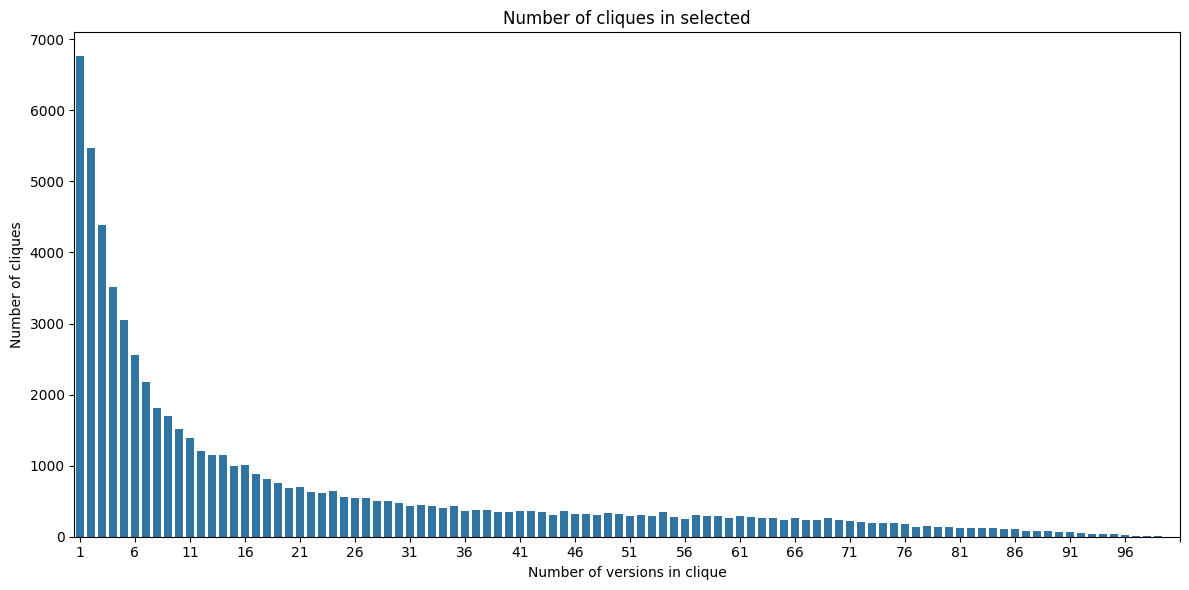

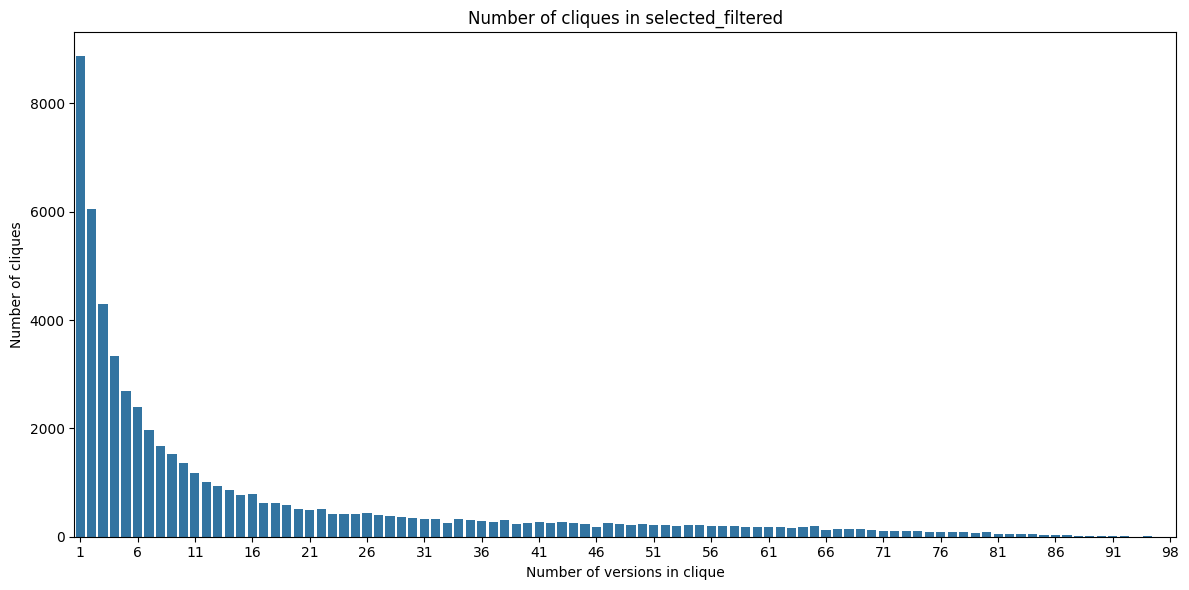

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_clique_size_distribution(selected, dataset_name):
    """
    Plots the distribution of clique sizes from the `selected` dictionary or DataFrame.

    Args:
        selected (dict or DataFrame): Must contain 'clique_id' repeated per YouTube ID.
        title (str): Title of the plot.

    Returns:
        None
    """
    # Compute distribution
    clique_sizes = selected['clique_id'].value_counts()
    size_distribution = clique_sizes.value_counts().sort_index()

    # Plot
    plt.figure(figsize=(12, 6))
    sns.barplot(x=size_distribution.index, y=size_distribution.values)

    plt.xticks(ticks=range(0, max(size_distribution.index)+1, 5))
    plt.title('Number of cliques in ' + dataset_name)
    plt.xlabel('Number of versions in clique')
    plt.ylabel('Number of cliques')
    plt.tight_layout()
    plt.show()

plot_clique_size_distribution(selected, "selected")
plot_clique_size_distribution(selected_filtered, "selected_filtered")


In [3]:
from tqdm import tqdm

# metadata = pd.read_json("data/metadata_filtered.jsonl", lines=True, orient='records')
metadata = pd.read_parquet("data/yt.parquet")

# Make tqdm work nicely with pandas apply
tqdm.pandas(desc="Processing tags")

def join_tags(item):
    if isinstance(item, list):
        return " ".join(str(x) for x in item)
    else:
        return ""

metadata["tags_str"] = metadata["tags"].progress_apply(join_tags)

metadata = metadata.loc[metadata.youtube_id.isin(selected.youtube_id),:]

new_columns = ["clique_id"] + metadata.columns.tolist()
metadata = pd.merge(
    selected.reset_index(),
    metadata.reset_index(drop=True),
    on="youtube_id",
    how="left",
)
metadata = metadata[new_columns]


Processing tags: 100%|██████████| 1180369/1180369 [00:00<00:00, 2291592.01it/s]


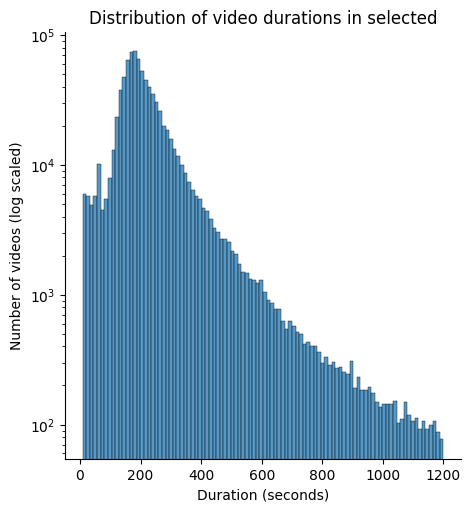

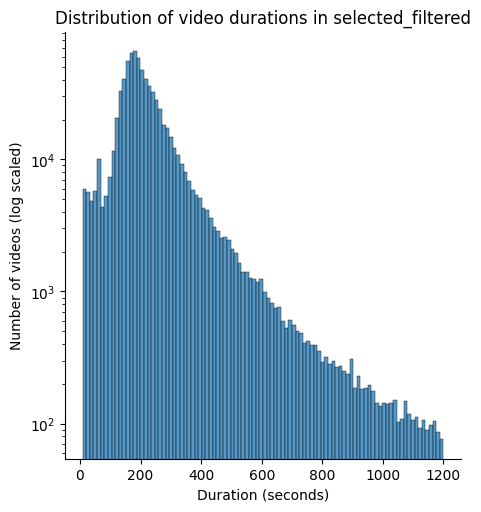

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_duration_distribution(metadata, dataset_name, bins=100):
    sns.displot(metadata, x="duration", bins=bins)
    plt.xlabel("Duration (seconds)")
    plt.ylabel("Number of videos (log scaled)")
    plt.yscale('log')  # <-- set y-axis to log scale
    plt.title('Distribution of video durations in ' + dataset_name)
    plt.show()

plot_duration_distribution(metadata, dataset_name="selected")
plot_duration_distribution(metadata.loc[metadata.youtube_id.isin(selected_filtered.youtube_id)], 
                           dataset_name="selected_filtered")
